<a href="https://colab.research.google.com/github/arsha-analyst/Telco-Customer-Churn-Analysis/blob/main/Data_Preparation/customer_churn_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Segmentation for Telco Customers

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [3]:
data=pd.read_csv("/content/drive/MyDrive/Dataset_ATS_v2.csv")
print(data.head(5))

   gender  SeniorCitizen Dependents  tenure PhoneService MultipleLines  \
0  Female              0         No       1           No            No   
1    Male              0         No      41          Yes            No   
2  Female              0        Yes      52          Yes            No   
3  Female              0         No       1          Yes            No   
4    Male              0         No      67          Yes            No   

  InternetService        Contract  MonthlyCharges Churn  
0             DSL  Month-to-month              25   Yes  
1             DSL        One year              25    No  
2             DSL  Month-to-month              19    No  
3             DSL        One year              76   Yes  
4     Fiber optic  Month-to-month              51    No  


In [ ]:
print(data.shape)

(7043, 10)


In [ ]:
#find missing values
print(data.isna().sum())

gender             0
SeniorCitizen      0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
Contract           0
MonthlyCharges     0
Churn              0
dtype: int64


In [ ]:
# identify  data types and confirm columns
print(f'The data has {data.shape[0]} rows and {data.shape[1]} features')
print(data.dtypes)

The data has 7043 rows and 10 features
gender             object
SeniorCitizen       int64
Dependents         object
tenure              int64
PhoneService       object
MultipleLines      object
InternetService    object
Contract           object
MonthlyCharges      int64
Churn              object
dtype: object


In [ ]:
#descriptive summary of the numerical features
print(data.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.758768
std         0.368612    24.559481       30.091650
min         0.000000     0.000000       18.000000
25%         0.000000     9.000000       36.000000
50%         0.000000    29.000000       70.000000
75%         0.000000    55.000000       90.000000
max         1.000000    72.000000      119.000000


### 1. Univariate Analysis

#### Numerical Features Visualization

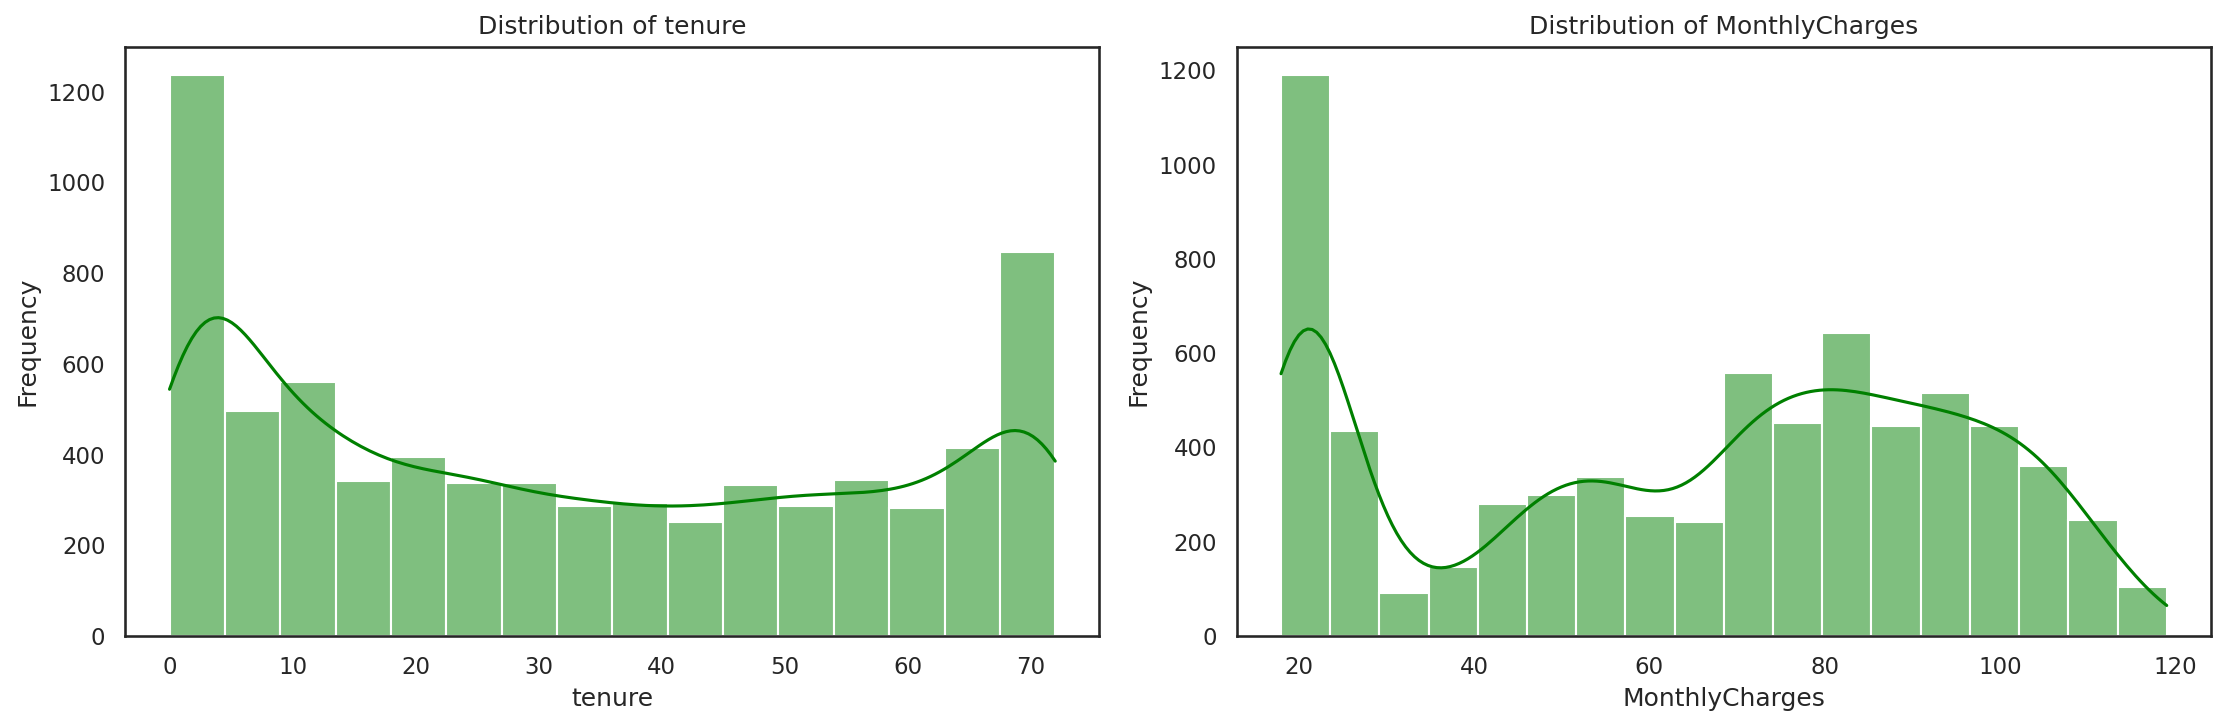

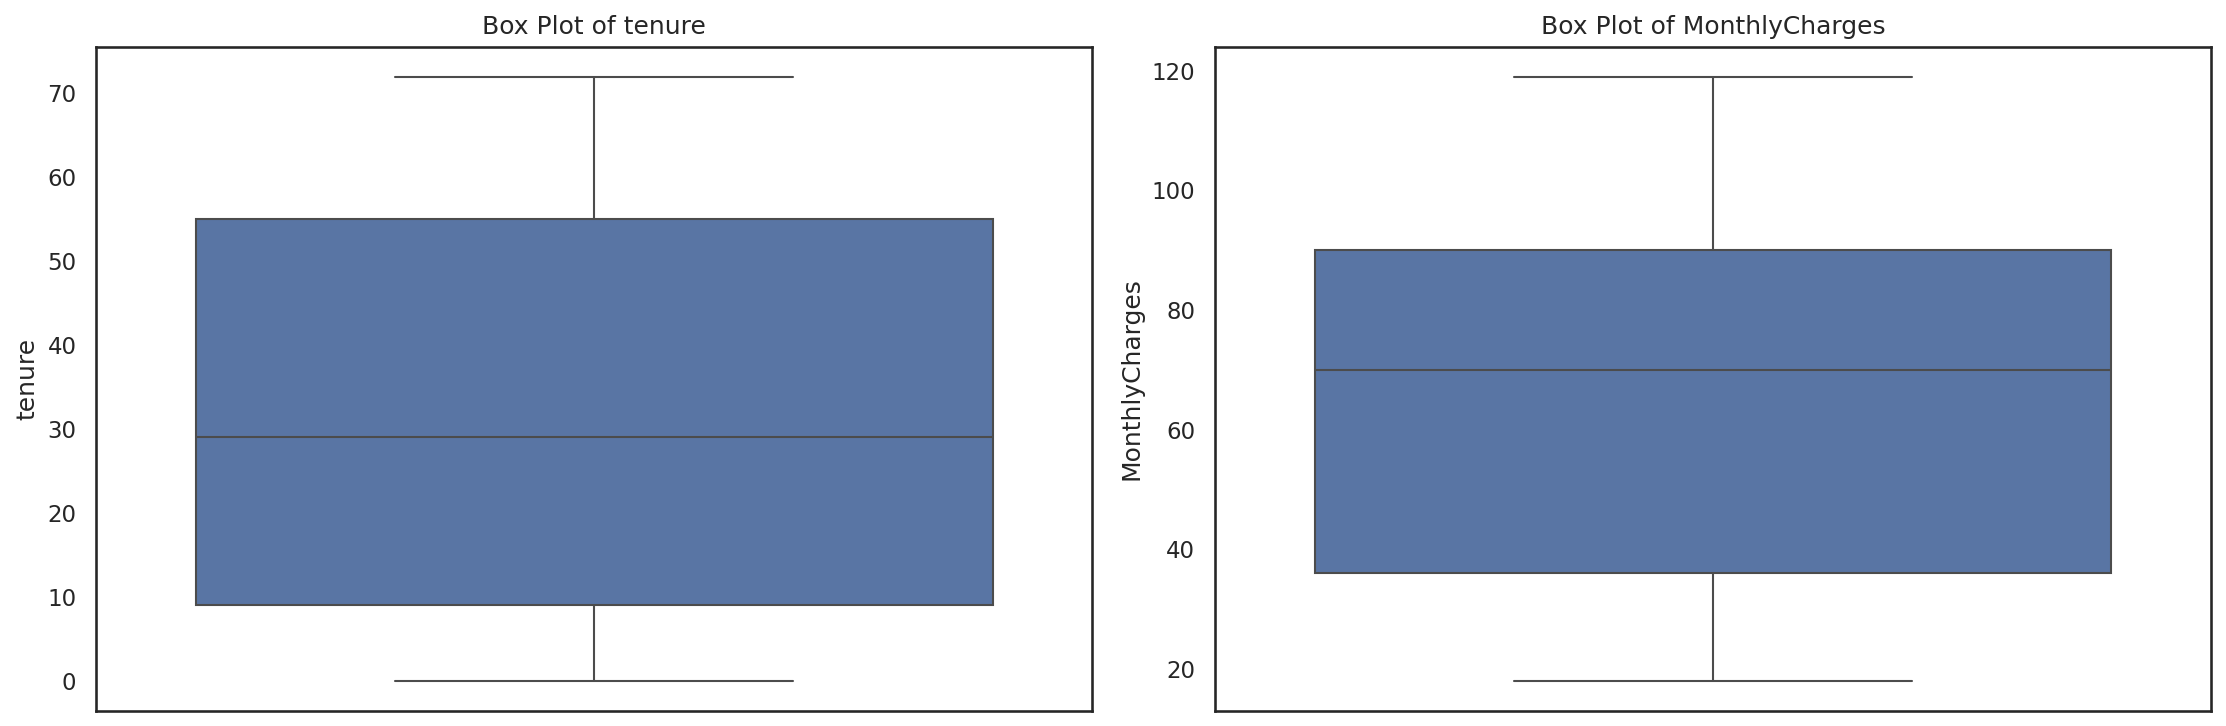

In [ ]:
numerical_features = ['tenure', 'MonthlyCharges']

plt.figure(figsize=(15, 5))
for i, feature in enumerate(numerical_features):
    plt.subplot(1, 2, i + 1)
    sns.histplot(data[feature], kde=True, color = 'green')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
for i, feature in enumerate(numerical_features):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(y=data[feature])
    plt.title(f'Box Plot of {feature}')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

#### Categorical Features Visualization

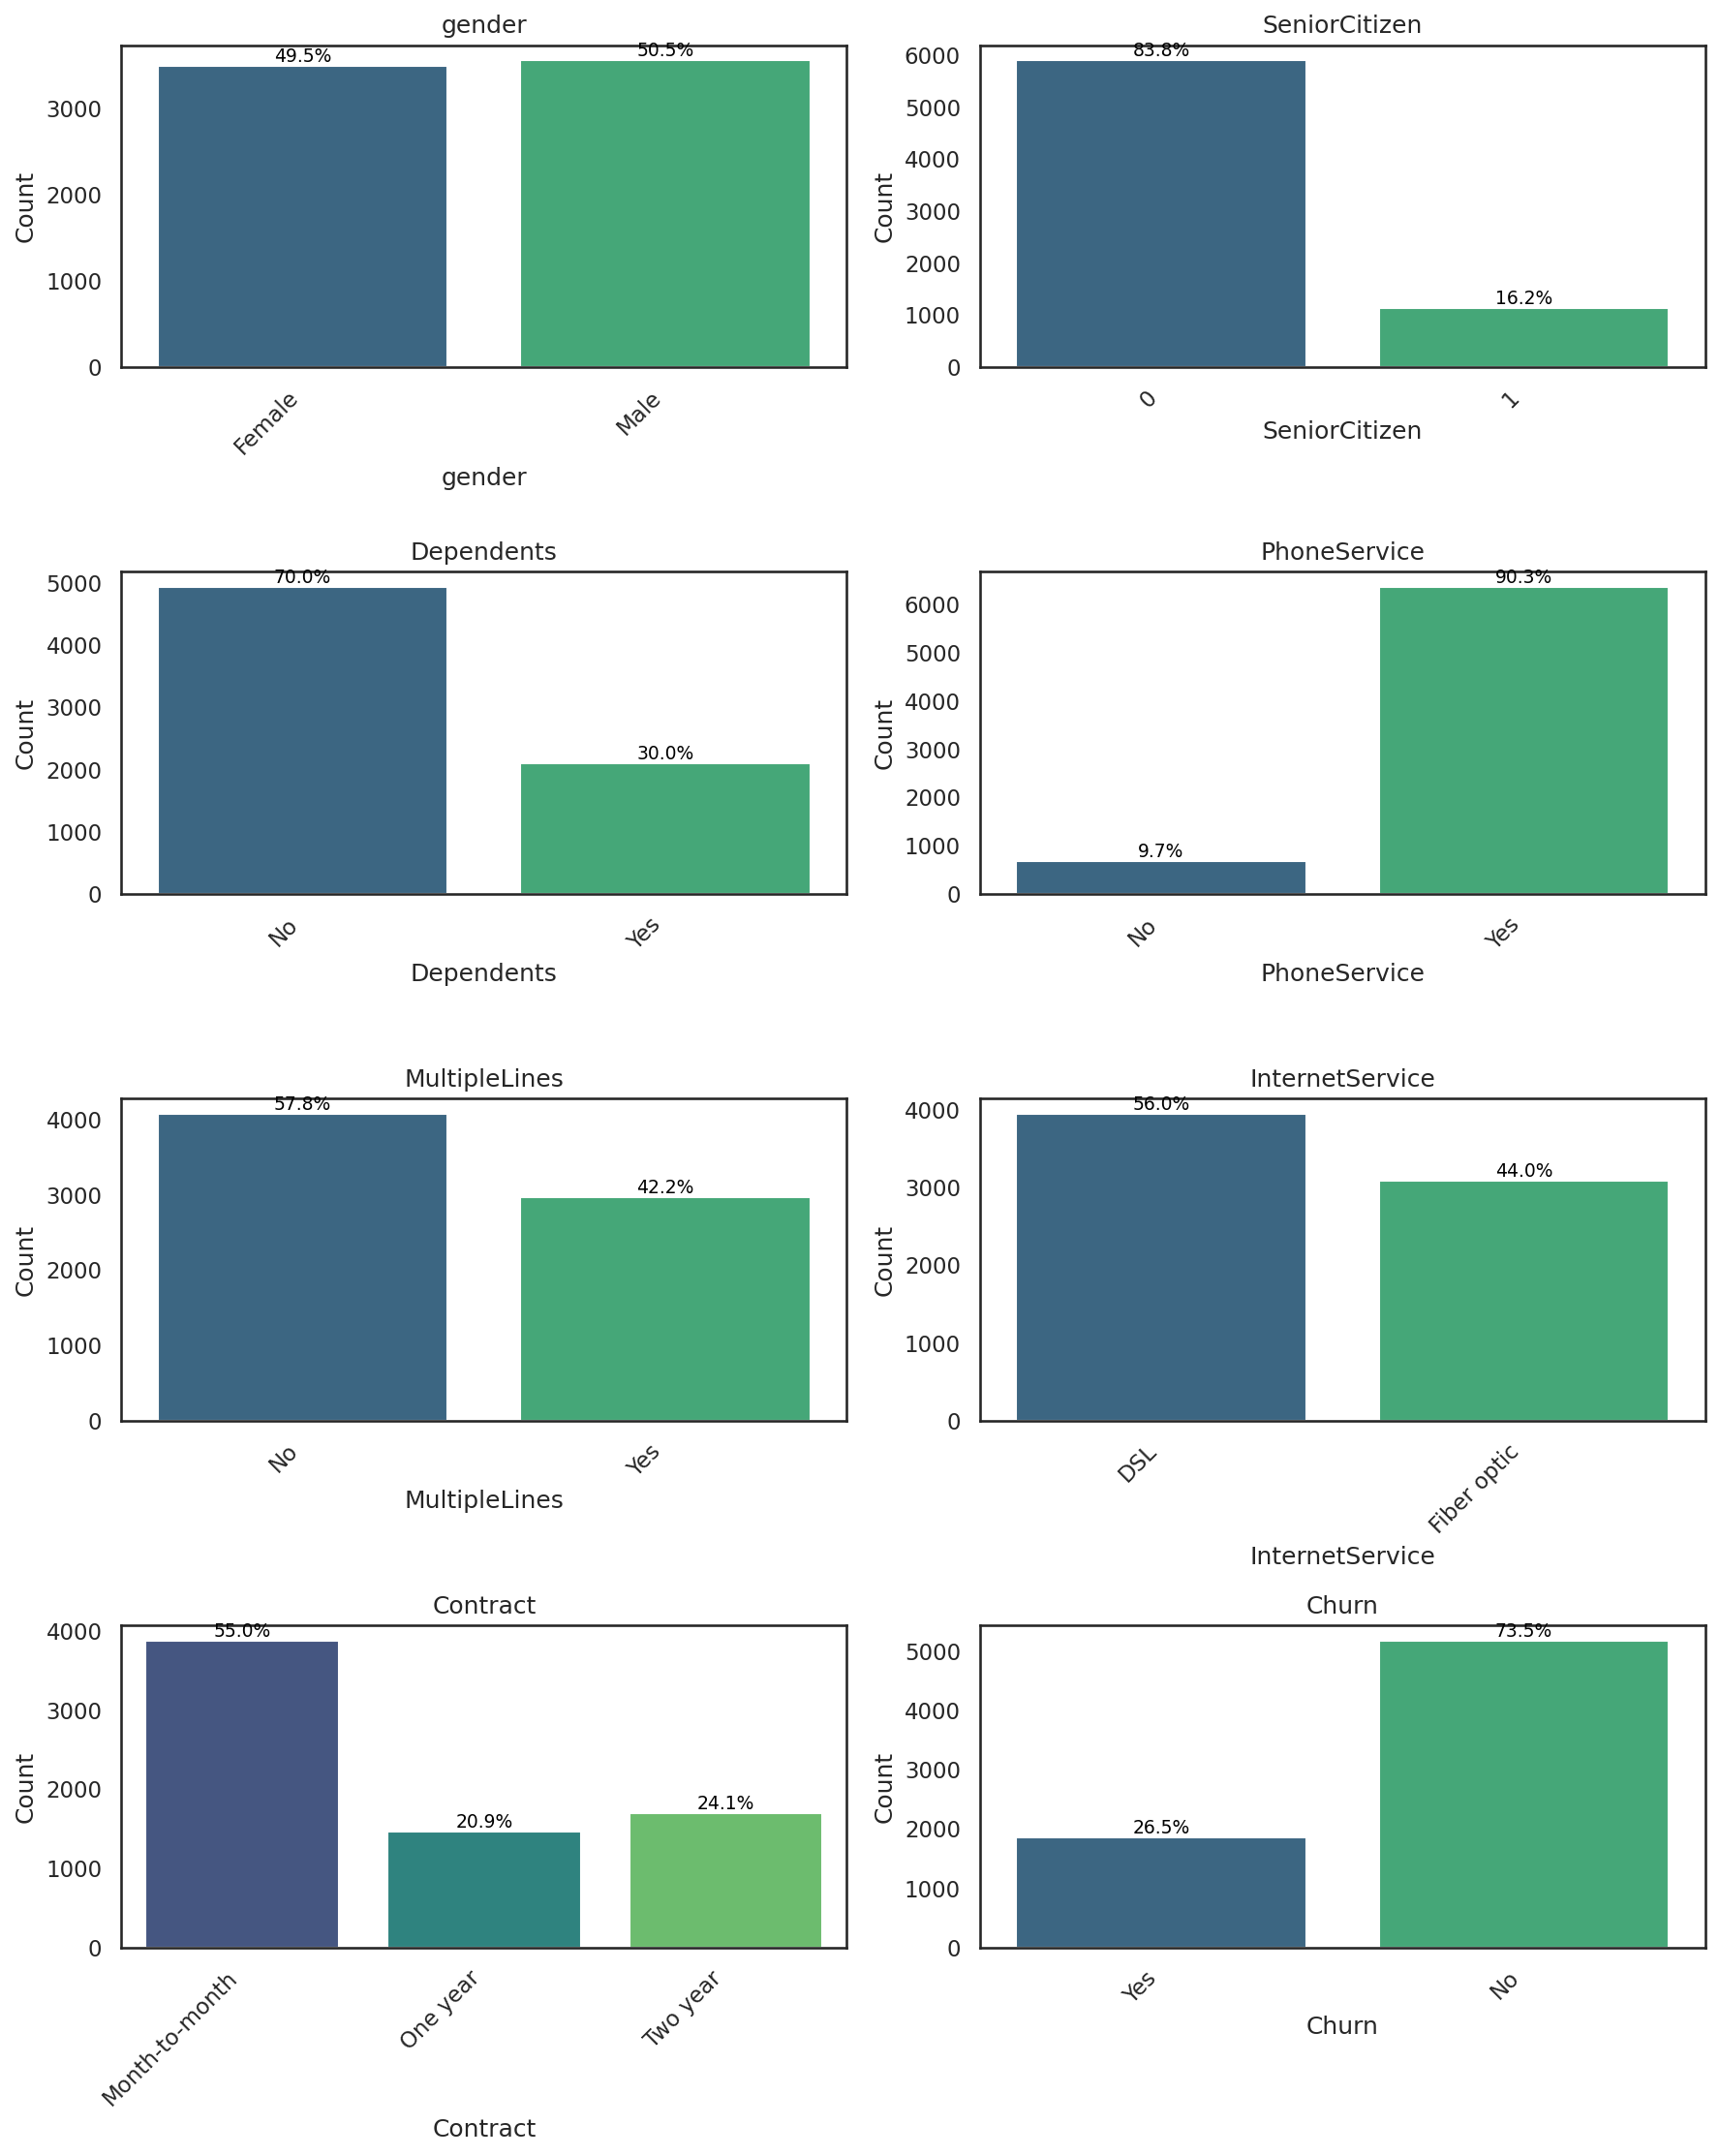

In [ ]:
categorical_features = ['gender', 'SeniorCitizen', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'Churn']

plt.figure(figsize=(12, 15))
for i, feature in enumerate(categorical_features):
    plt.subplot(4, 2, i + 1)
    ax = sns.countplot(x=data[feature], hue=data[feature], palette='viridis', legend=False)
    plt.title(f'{feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

    # calculate percentages and add labels
    total = len(data[feature])
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=9, color='black')

plt.tight_layout()
plt.show()

### 2. Bivariate Analysis

How does the independent features relate to the target variable?

#### Numerical Features vs. Churn

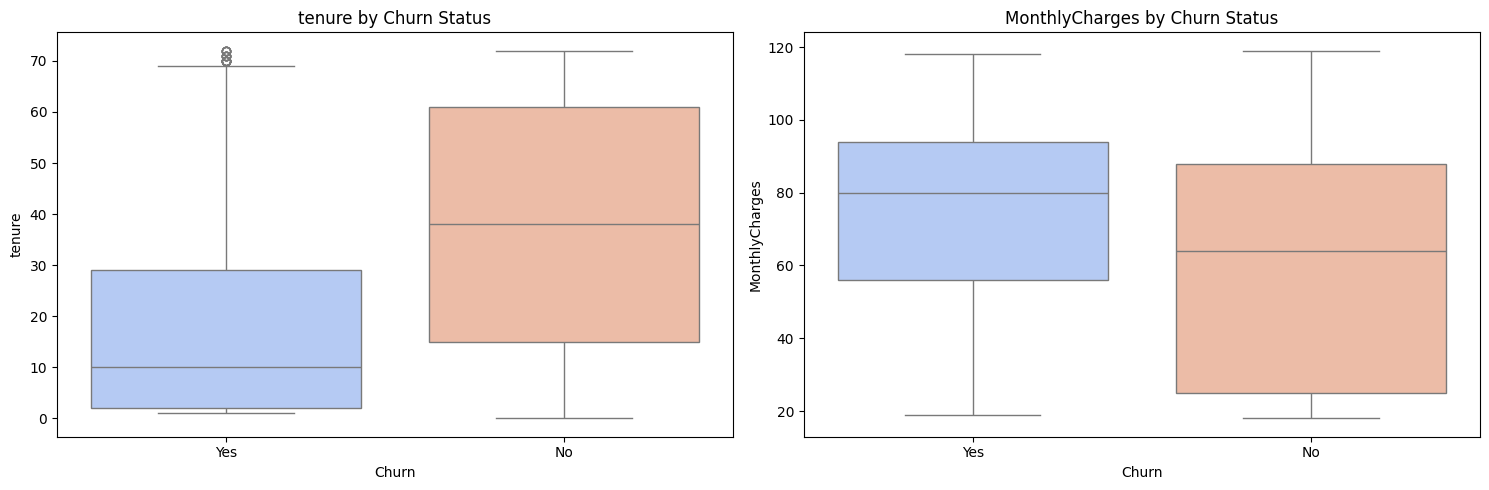

In [ ]:
plt.figure(figsize=(15, 5))
for i, feature in enumerate(numerical_features):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(x='Churn', y=feature, data=data, palette='coolwarm')
    plt.title(f'{feature} by Churn Status')
    plt.xlabel('Churn')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

#### Independent Samples t-test (Numerical vs. Categorical)

In [4]:
churn_yes = data[data['Churn'] == 'Yes']['MonthlyCharges']
churn_no = data[data['Churn'] == 'No']['MonthlyCharges']

t_statistic, p_value = ttest_ind(churn_yes, churn_no, equal_var=False) # Welch's t-test assuming unequal variances

print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Conclusion: There is a statistically significant difference in MonthlyCharges between churned and retained customers.")
else:
    print("Conclusion: There is no statistically significant difference in MonthlyCharges between churned and retained customers.")

T-statistic: 18.39
P-value: 0.000
Conclusion: There is a statistically significant difference in MonthlyCharges between churned and retained customers.


In [ ]:
churn_yes = data[data['Churn'] == 'Yes']['tenure']
churn_no = data[data['Churn'] == 'No']['tenure']

t_statistic, p_value = ttest_ind(
    churn_yes,
    churn_no,
    equal_var=False
)  # Welch's t-test assuming unequal variances

print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Conclusion: There is a statistically significant difference in tenure between churned and retained customers.")
else:
    print("Conclusion: There is no statistically significant difference in tenure between churned and retained customers.")

T-statistic: -34.82
P-value: 0.000
Conclusion: There is a statistically significant difference in tenure between churned and retained customers.


#### Categorical Features vs. Churn

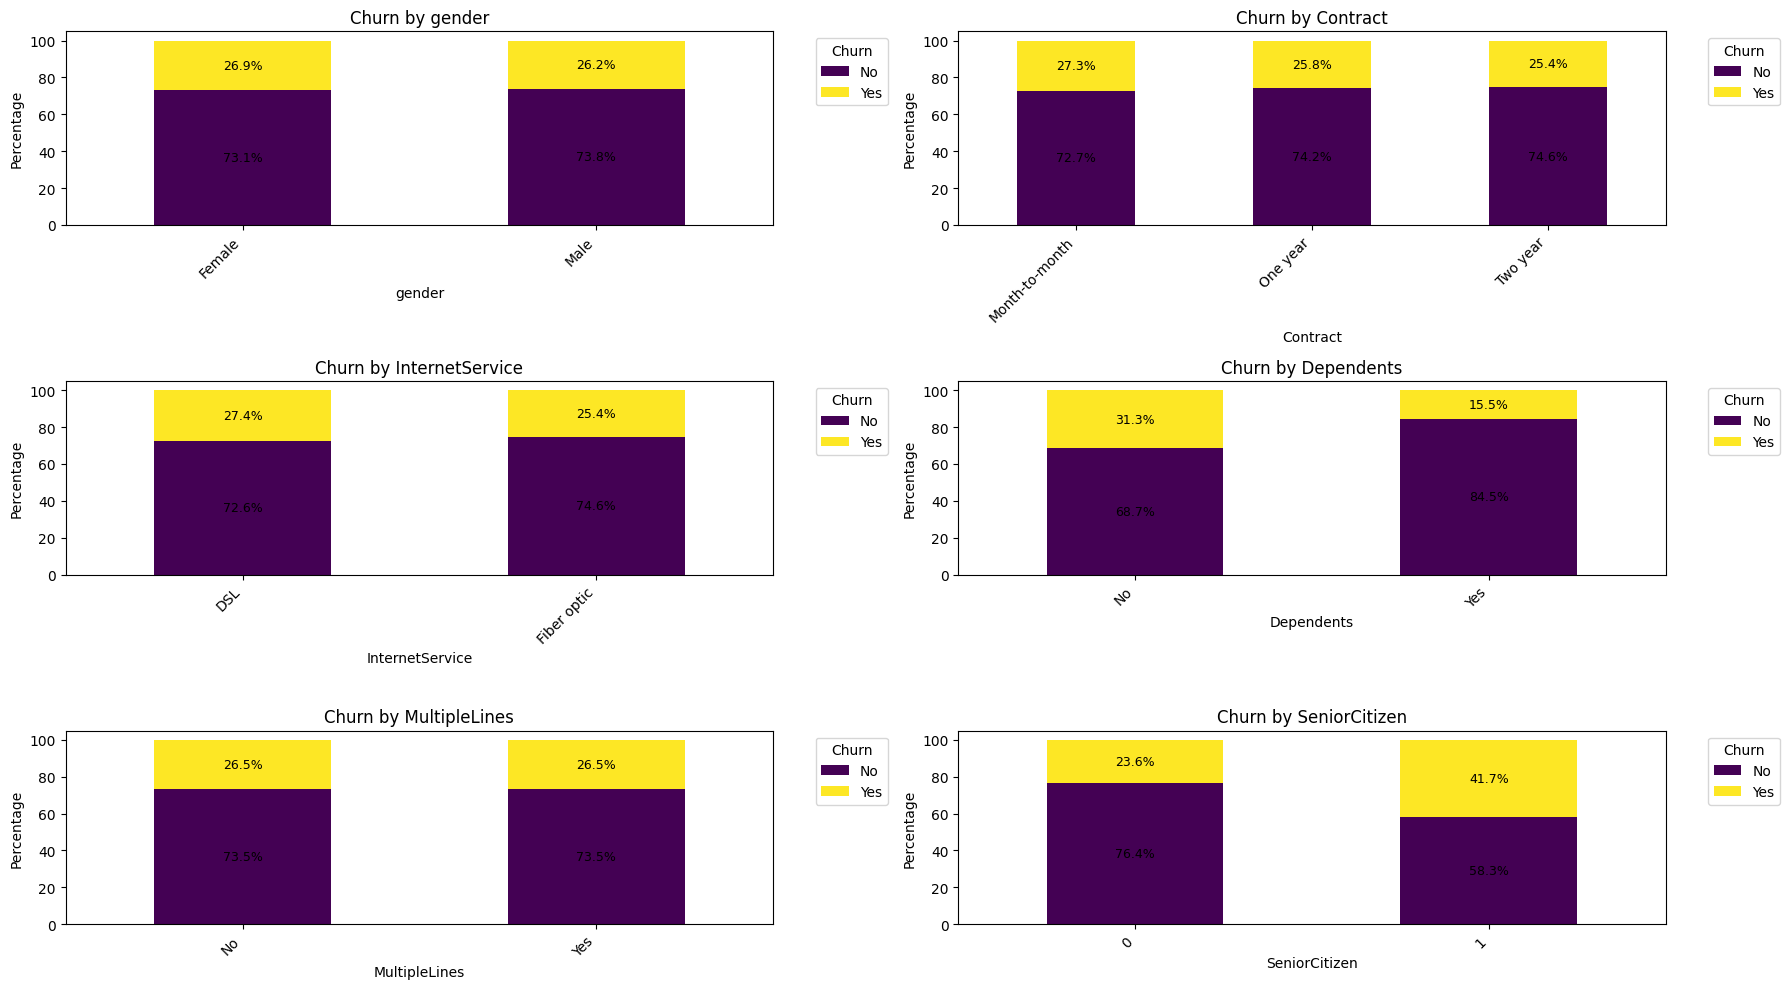

In [ ]:
features_to_compare = ['gender','Contract', 'InternetService', 'Dependents','MultipleLines', 'SeniorCitizen'] # Selected features

plt.figure(figsize=(20, 10))
for i, feature in enumerate(features_to_compare):
    plt.subplot(3, 2, i + 1)
    churn_by_feature = data.groupby([feature, 'Churn']).size().unstack(fill_value=0)

    # Calculate percentages
    churn_percentages = churn_by_feature.div(churn_by_feature.sum(axis=1), axis=0) * 100

    ax = churn_percentages.plot(kind='bar', stacked=True, ax=plt.gca(), cmap='viridis')
    plt.title(f'Churn by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Percentage')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Add percentage labels
    for container in ax.containers:
        for patch in container.patches:
            height = patch.get_height()
            width = patch.get_width()
            x, y = patch.get_xy()
            if height > 0: # Only label non-zero segments
                ax.text(x + width / 2, y + height / 2, f'{height:.1f}%',
                        ha='center', va='center', color='black', fontsize=9)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

#### Chi-Square Test for Independence (Categorical vs. Categorical (Churn))

In [ ]:
def chi_square_test(data, categorical_variable, target='Churn'):
    # Create contingency table
    table = pd.crosstab(data[categorical_variable], data[target])

    # Chi-Square test
    chi2, p_value, dof, expected = chi2_contingency(table)

    print(f"\nChi-Square Test: {categorical_variable} vs {target}")
    print("-" * 50)
    print("Chi-Square Statistic:", chi2)
    print("P-value:", p_value)
    print("Degrees of Freedom:", dof)

    if p_value < 0.05:
        print("Conclusion: Significant association")
    else:
        print("Conclusion: No significant association")

    return chi2, p_value, dof, expected


chi_square_test(data, 'gender')
chi_square_test(data, 'Contract')
chi_square_test(data, 'InternetService')
chi_square_test(data, 'Dependents')
chi_square_test(data, 'MultipleLines')


Chi-Square Test: gender vs Churn
--------------------------------------------------
Chi-Square Statistic: 0.4840828822091383
P-value: 0.48657873605618596
Degrees of Freedom: 1
Conclusion: No significant association

Chi-Square Test: Contract vs Churn
--------------------------------------------------
Chi-Square Statistic: 2.84658271619807
P-value: 0.2409197573232328
Degrees of Freedom: 2
Conclusion: No significant association

Chi-Square Test: InternetService vs Churn
--------------------------------------------------
Chi-Square Statistic: 3.434779917987427
P-value: 0.06383708992967259
Degrees of Freedom: 1
Conclusion: No significant association

Chi-Square Test: Dependents vs Churn
--------------------------------------------------
Chi-Square Statistic: 189.12924940423474
P-value: 4.9249216612154196e-43
Degrees of Freedom: 1
Conclusion: Significant association

Chi-Square Test: MultipleLines vs Churn
--------------------------------------------------
Chi-Square Statistic: 0.0
P-value

(np.float64(0.0),
 np.float64(1.0),
 1,
 array([[2991.41388613, 1080.58611387],
        [2182.58611387,  788.41388613]]))

### 3. Correlation Analysis
Is there correlation between numerical features?

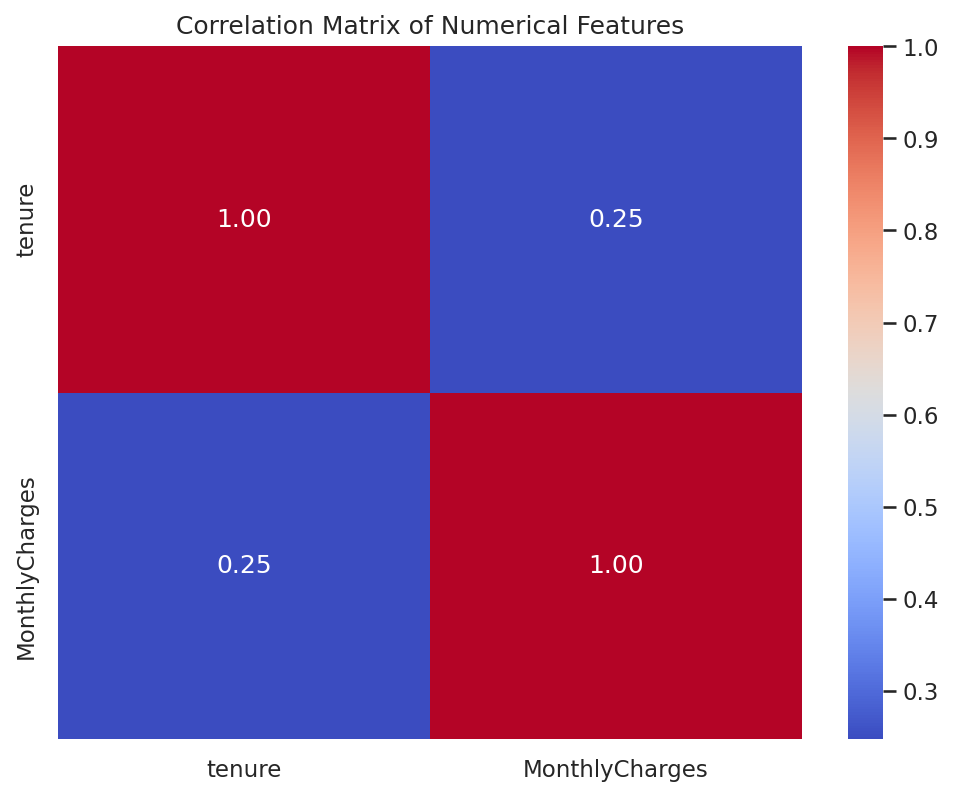

In [ ]:
correlation_matrix = data[numerical_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Derived Variables Analysis

Results from the univariate analysis show multimodal distributions for Monthly charges and tenure. That information gives us three groups for each of them.  

In [11]:
def analyze_chi2(df, feature_col, target_col='Churn'):
  """contingency table creation, Chi-Square test, and prints churn percentages."""
  print(f'-' * 50)
  print(f'{feature_col}')
  print(f'-' * 50)

  # ontingency table
  contingency_table = pd.crosstab(df[feature_col], df[target_col])
  #print('\n--- Contingency Table (Counts) ---')
  #print(contingency_table)

  # Chi-Square Test
  chi2, p_val, dof, expected = chi2_contingency(contingency_table)
  print(f'\nChi-Square Statistic: {chi2:.4f}')
  print(f'P-value: {p_val:.4e}')
  print(f'Degrees of Freedom: {dof}')

  if p_val < 0.05:
    print('Statistically significant association with Churn.')
  else:
    print('NO statistically significant association with Churn.')

  # churn rate breakdown %
  churn_percentages = (
      pd.crosstab(df[feature_col], df[target_col], normalize='index') * 100
  )
  print('\n Churn Rate by Group (%)')
  print(churn_percentages.round(2))
  print('\n')


# binning numerical variable into 3 groups

# tenure groups
data['Tenure_Groups'] = pd.cut(
    data['tenure'],
    bins=[-1, 12, 48, 72],
    labels=['Low (0-12m)', 'Medium (13-48m)', 'High (49-72m)'],
)

# monthly harges groups
data['MonthlyCharges_Groups'] = pd.cut(
    data['MonthlyCharges'],
    bins=[0, 35, 70, 150],
    labels=['Low ($0-$35)', 'Medium ($35.01-$70)', 'High ($70.01+)'],
)

#Chi-Square analysis
analyze_chi2(data, 'Tenure_Groups')
analyze_chi2(data, 'MonthlyCharges_Groups')

--------------------------------------------------
Tenure_Groups
--------------------------------------------------

Chi-Square Statistic: 833.9514
P-value: 8.1238e-182
Degrees of Freedom: 2
Statistically significant association with Churn.

 Churn Rate by Group (%)
Churn               No    Yes
Tenure_Groups                
Low (0-12m)      52.56  47.44
Medium (13-48m)  76.36  23.64
High (49-72m)    90.49   9.51


--------------------------------------------------
MonthlyCharges_Groups
--------------------------------------------------

Chi-Square Statistic: 346.3426
P-value: 6.2037e-76
Degrees of Freedom: 2
Statistically significant association with Churn.

 Churn Rate by Group (%)
Churn                     No    Yes
MonthlyCharges_Groups              
Low ($0-$35)           88.74  11.26
Medium ($35.01-$70)    75.24  24.76
High ($70.01+)         64.85  35.15




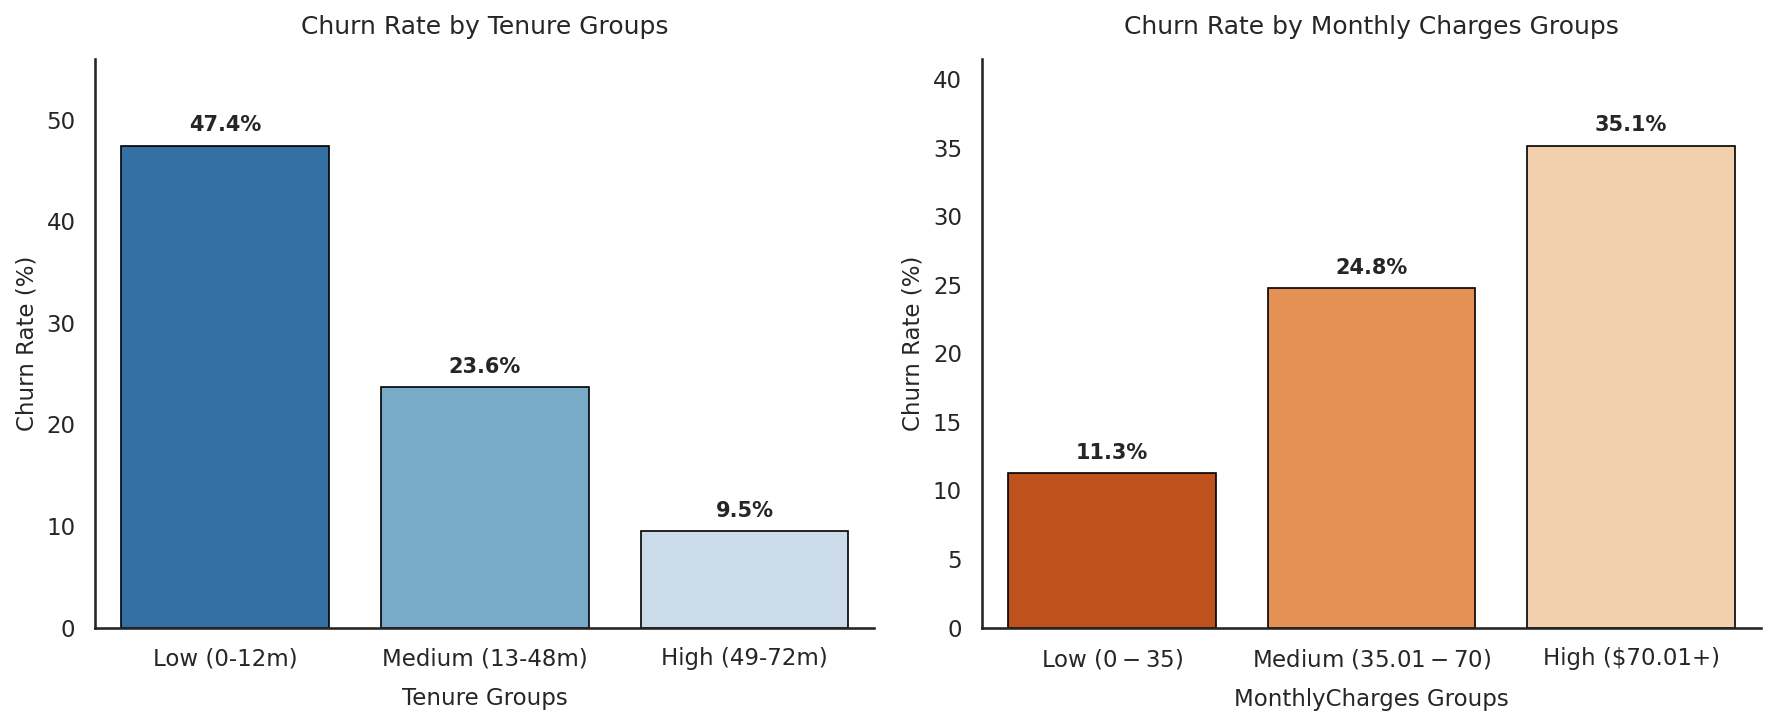

In [12]:
sns.set_theme(style="white")
plt.rcParams.update({"font.family": "sans-serif", "figure.dpi": 150})


def plot_churn_subplot(
    df, group_col, title, ax, color_palette="Blues_r", target_col="Churn"
):
  """Plots churn percentage per group on a specific subplot axis."""
  # calculating churn rate%
  churn_df = (
      df.groupby(group_col, observed=False)[target_col]
      .value_counts(normalize=True)
      .unstack()
      .reset_index()
  )

  churn_df["Churn_Rate"] = churn_df["Yes"] * 100

  # barplot
  bars = sns.barplot(
      data=churn_df,
      x=group_col,
      y="Churn_Rate",
      palette=color_palette,
      edgecolor="black",
      linewidth=0.8,
      ax=ax,
  )

  # add data labels on top of bars
  for bar in bars.patches:
    height = bar.get_height()
    if height > 0:
      ax.annotate(
          f"{height:.1f}%",
          xy=(bar.get_x() + bar.get_width() / 2, height),
          xytext=(0, 5),
          textcoords="offset points",
          ha="center",
          va="bottom",
          fontsize=10,
          fontweight="bold",
      )

  # formatting subplot
  ax.set_title(title, fontsize=12, pad=12)
  ax.set_xlabel(group_col.replace("_", " "), fontsize=11, labelpad=8)
  ax.set_ylabel("Churn Rate (%)", fontsize=11)
  ax.set_ylim(0, max(churn_df["Churn_Rate"]) * 1.18)
  sns.despine(ax=ax, top=True, right=True, left=False)


# 1 x 2 grid layout
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# tenure groups
plot_churn_subplot(
    data,
    "Tenure_Groups",
    "Churn Rate by Tenure Groups",
    ax=axes[0],
    color_palette="Blues_r",
)

#Monthly Charges Groups
plot_churn_subplot(
    data,
    "MonthlyCharges_Groups",
    "Churn Rate by Monthly Charges Groups",
    ax=axes[1],
    color_palette="Oranges_r",
)

plt.tight_layout()
plt.show()

In [ ]:
print(data.head())

   gender  SeniorCitizen Dependents  tenure PhoneService MultipleLines  \
0  Female              0         No       1           No            No   
1    Male              0         No      41          Yes            No   
2  Female              0        Yes      52          Yes            No   
3  Female              0         No       1          Yes            No   
4    Male              0         No      67          Yes            No   

  InternetService        Contract  MonthlyCharges Churn    Tenure_Groups  \
0             DSL  Month-to-month              25   Yes      Low (0-12m)   
1             DSL        One year              25    No  Medium (13-48m)   
2             DSL  Month-to-month              19    No    High (49-72m)   
3             DSL        One year              76   Yes      Low (0-12m)   
4     Fiber optic  Month-to-month              51    No    High (49-72m)   

  MonthlyCharges_Groups  
0          Low ($0-$35)  
1          Low ($0-$35)  
2          Low ($0-$

# Feature Selection and Data Preprocessing for Cluster Analysis

We have identified statistically significan association between our target variable (Churn) Dependents, tenure, MonthlyCharges, Tenure_Groups and MonthlyCharges_Groups. To avoid multicolinearity we will drop the continous data type of tenure and MonthlyCharges and instead worked with their respective grouped version. Any other variable rejected by statistical tests in section 3 does not qualify as a predictors of churn. Therefore we drop them from the modelling features.

In [17]:

# selecting features for clustering
clustering_features = ['Dependents', 'Tenure_Groups', 'MonthlyCharges_Groups']
X = data[clustering_features]

#one-hot encoding for the selected categorical features
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_encoded = encoder.fit_transform(X)

# store the encoded features in adataframe for better readability and future use
X_encoded_df = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(clustering_features))

print("Shape of the encoded data:", X_encoded_df.shape)
display(X_encoded_df.head())

Shape of the encoded data: (7043, 8)


,Dependents_No,Dependents_Yes,Tenure_Groups_High (49-72m),Tenure_Groups_Low (0-12m),Tenure_Groups_Medium (13-48m),MonthlyCharges_Groups_High ($70.01+),MonthlyCharges_Groups_Low ($0-$35),MonthlyCharges_Groups_Medium ($35.01-$70)
0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


we will split the encoded data into training and testing sets. For K-Means, which is an unsupervised algorithm, we typically split the feature set X itself.

In [18]:
# split the encoded data into training and testing sets
X_train, X_test = train_test_split(X_encoded_df, test_size=0.2, random_state=42)

print("Shape of training set:", X_train.shape)
print("Shape of testing set:", X_test.shape)
display(X_train.head())

Shape of training set: (5634, 8)
Shape of testing set: (1409, 8)


,Dependents_No,Dependents_Yes,Tenure_Groups_High (49-72m),Tenure_Groups_Low (0-12m),Tenure_Groups_Medium (13-48m),MonthlyCharges_Groups_High ($70.01+),MonthlyCharges_Groups_Low ($0-$35),MonthlyCharges_Groups_Medium ($35.01-$70)
2142,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1623,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
6074,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1362,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
6754,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [19]:
#store the sets in google drive
X_train.to_csv('/content/drive/MyDrive/X_train.csv', index=False)
X_test.to_csv('/content/drive/MyDrive/X_test.csv', index=False)